In [43]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
import numpy as np
from tqdm import tqdm
import torch
import torch.nn as nn
import torchani
import os
import matplotlib.pyplot as plt
import pandas as pd
import itertools

In [51]:
class ANITrainer:
    def __init__(self, model, batch_size=256, learning_rate=5e-4, epoch=30, l2=1e-6):
        self.model = model
        
        self.batch_size = batch_size
        num_params = sum(p.numel() for p in model.parameters())
        print(f"{model.__class__.__name__} - Number of parameters: {num_params}")
        self.optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=l2)
        self.epoch = epoch


    def train(self, train_data, val_data, early_stop=True, draw_curve=True):
        self.model.train()
        
        # init data loader
        print("Initialize training data...")
        train_data_loader = train_data.collate(self.batch_size).cache()
        
        # definition of loss function: MSE is a good choice! 
        loss_func = nn.MSELoss()
        
        # record epoch losses
        train_loss_list = []
        val_loss_list = []
        lowest_val_loss = np.inf
        
        for i in tqdm(range(self.epoch), leave=True):
            train_epoch_loss = 0.0
            n_total= 0.0
            for train_data_batch in train_data_loader:
                
                # compute energies
                species = train_data_batch['species'].to(device)
                coords = train_data_batch['coordinates'].to(device)
                true_energies = train_data_batch['energies'].to(device).float()
                _, pred_energies = self.model((species, coords))
                
                # compute loss
                batch_loss = loss_func(true_energies, pred_energies)
                
                # do a step
                self.optimizer.zero_grad()
                batch_loss.backward()
                self.optimizer.step()
                
                batch_importance = true_energies.shape[0]
                train_epoch_loss += batch_loss.item() * batch_importance
                n_total += batch_importance
            
            train_epoch_loss /= max(n_total, 1)
            # use the self.evaluate to get loss on the validation set 
            _, val_mae = self.evaluate(val_data, draw_plot=False, return_mae=True)
            
            # append the losses
            train_loss_list.append(train_epoch_loss)
            val_loss_list.append(val_mae)
            
            if early_stop:
                if val_mae < lowest_val_loss:
                    lowest_val_loss = val_mae
                    weights = {k: v.clone() for k, v in self.model.state_dict().items()}
        
        if draw_curve:
            fig, ax = plt.subplots(1, 1, figsize=(5, 4), constrained_layout=True)
            ax.set_yscale("log")
            # Plot train loss and validation loss
            ax.plot(range(len(train_loss_list)), train_loss_list, label='Train')
            ax.plot(range(len(val_loss_list)), val_loss_list, label='Validation MAE (kcal/mol)')
            ax.legend()
            ax.set_xlabel("Epoch")
            ax.set_ylabel("Loss")
        
        if early_stop:
            self.model.load_state_dict(weights)
        
        return train_loss_list, val_loss_list
    
    
    def evaluate(self, data, draw_plot=False, return_mae=False):

        self.model.eval()
        
        # init data loader
        data_loader = data.collate(self.batch_size).cache()
        
        # init loss function
        loss_func = nn.MSELoss()
        total_loss = 0.0
        
        if draw_plot or return_mae:
            true_energies_all = []
            pred_energies_all = []
            
        with torch.no_grad():
            for batch_data in data_loader:
                
                # compute energies
                species = batch_data['species'].to(device)
                coords = batch_data['coordinates'].to(device)
                true_energies = batch_data['energies'].to(device).float()
                species_out, pred_energies = self.model((species, coords))
                
                # compute loss
                batch_loss = loss_func(true_energies, pred_energies)

                batch_importance = true_energies.shape[0]
                total_loss += batch_loss.item() * batch_importance
                
                if draw_plot or return_mae:
                    true_energies_all.append(true_energies.detach().cpu().numpy().flatten())
                    pred_energies_all.append(pred_energies.detach().cpu().numpy().flatten())


        mae = None
        if draw_plot or return_mae:
            true_energies_all = np.concatenate(true_energies_all)
            pred_energies_all = np.concatenate(pred_energies_all)
            # Report the mean absolute error
            # The unit of energies in the dataset is hartree
            # please convert it to kcal/mol when reporting the mean absolute error
            # 1 hartree = 627.5094738898777 kcal/mol
            # MAE = mean(|true - pred|)
            hartree2kcalmol = 627.5094738898777
            mae = np.mean(np.abs(true_energies_all - pred_energies_all)) * hartree2kcalmol

        if draw_plot:
            fig, ax = plt.subplots(1, 1, figsize=(5, 4), constrained_layout=True)
            ax.scatter(true_energies_all, pred_energies_all, label=f"MAE: {mae:.2f} kcal/mol", s=2)
            ax.set_xlabel("Ground Truth")
            ax.set_ylabel("Predicted")
            xmin, xmax = ax.get_xlim()
            ymin, ymax = ax.get_ylim()
            vmin, vmax = min(xmin, ymin), max(xmax, ymax)
            ax.set_xlim(vmin, vmax)
            ax.set_ylim(vmin, vmax)
            ax.plot([vmin, vmax], [vmin, vmax], color='red')
            ax.legend()

        if return_mae:
            return total_loss, mae

        return total_loss       

In [45]:
# Importing Model
import torch
import torch.nn as nn
import torchani

print("torch:", torch.__version__)
print("torchani:", torchani.__version__)

import numpy as np
from tqdm import tqdm
import os
import matplotlib.pyplot as plt

torch: 2.3.1+cu118
torchani: 2.2.4


In [46]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cpu


In [47]:
class AtomicNet(nn.Module):
    def __init__(self, aev_dim, hidden_layers, dropout=0.0):
        super().__init__()
        layers = []
        in_dim = aev_dim
        for h_dim in hidden_layers:
            layers.append(nn.Linear(in_dim, h_dim))
            layers.append(nn.ReLU())
            if dropout > 0.0:
                layers.append(nn.Dropout(dropout))
            in_dim = h_dim
        layers.append(nn.Linear(in_dim, 1))
        self.layers = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.layers(x)

def build_model(aev_computer, aev_dim, hidden_layers, dropout):
    # Initialize fresh atomic networks for each element (H, C, N, O)
    net_H = AtomicNet(aev_dim, hidden_layers, dropout)
    net_C = AtomicNet(aev_dim, hidden_layers, dropout)
    net_N = AtomicNet(aev_dim, hidden_layers, dropout)
    net_O = AtomicNet(aev_dim, hidden_layers, dropout)

    ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
    model = nn.Sequential(
        aev_computer,
        ani_net
    ).to(device)
    return model

In [48]:
def init_aev_computer():
    Rcr = 5.2
    Rca = 3.5
    EtaR = torch.tensor([16], dtype=torch.float, device=device)
    ShfR = torch.tensor([
        0.900000, 1.168750, 1.437500, 1.706250, 
        1.975000, 2.243750, 2.512500, 2.781250, 
        3.050000, 3.318750, 3.587500, 3.856250, 
        4.125000, 4.393750, 4.662500, 4.931250
    ], dtype=torch.float, device=device)


    EtaA = torch.tensor([8], dtype=torch.float, device=device)
    Zeta = torch.tensor([32], dtype=torch.float, device=device)
    ShfA = torch.tensor([0.90, 1.55, 2.20, 2.85], dtype=torch.float, device=device)
    ShfZ = torch.tensor([
        0.19634954, 0.58904862, 0.9817477, 1.37444680, 
        1.76714590, 2.15984490, 2.5525440, 2.94524300
    ], dtype=torch.float, device=device)

    num_species = 4
    aev_computer = torchani.AEVComputer(
        Rcr, Rca, EtaR, ShfR, EtaA, Zeta, ShfA, ShfZ, num_species
    )
    return aev_computer

aev_computer = init_aev_computer()
aev_dim = aev_computer.aev_length
print(aev_dim)

384


In [40]:
def load_ani_dataset(dspath):
    self_energies = torch.tensor([
        0.500607632585, -37.8302333826,
        -54.5680045287, -75.0362229210
    ], dtype=torch.float, device=device)
    energy_shifter = torchani.utils.EnergyShifter(None)
    species_order = ['H', 'C', 'N', 'O']

    dataset = torchani.data.load(dspath)
    dataset = dataset.subtract_self_energies(energy_shifter, species_order)
    dataset = dataset.species_to_indices(species_order)
    dataset = dataset.shuffle()
    return dataset

dataset = load_ani_dataset("/global/scratch/users/mahikabansal/c142_project/ani_gdb_s01_to_s04.h5")
# Use dataset.split method to do split
train_data, val_data, test_data = dataset.split(0.8, 0.1, None)

In [41]:
class AtomicNet(nn.Module):
    def __init__(self, aev_dim=384, hidden_sizes=(256, 192, 160), dropout=0.1):
        super().__init__()
        super().__init__()
        layers = []
        in_dim = aev_dim

        for h in hidden_sizes:
            layers.append(nn.Linear(in_dim, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            in_dim = h

        layers.append(nn.Linear(in_dim, 1))
        self.layers = nn.Sequential(*layers)

    def forward(self, x):
        return self.layers(x)

aev_computer = init_aev_computer()

net_H = AtomicNet(aev_dim=aev_computer.aev_length)
net_C = AtomicNet(aev_dim=aev_computer.aev_length)
net_N = AtomicNet(aev_dim=aev_computer.aev_length)
net_O = AtomicNet(aev_dim=aev_computer.aev_length)

# ANI model requires a network for each atom type
# use torch.ANIModel() to compile atomic networks
ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
model = nn.Sequential(
    aev_computer,
    ani_net
).to(device)

In [ ]:
# Hyperparameter Grid
hidden_layers_list = [
    [128]
]
learning_rates = [1e-3, 1e-4]
epochs_list    = [10]           
l2_list        = [1e-5]
dropout_list   = [0.0, 0.1]

results = []

for hidden_layers, lr, epochs, l2, dropout in itertools.product(
    hidden_layers_list, learning_rates, epochs_list, l2_list, dropout_list
):
    print(f"Training: hidden={hidden_layers}, lr={lr}, epochs={epochs}, l2={l2}, dropout={dropout}")
    
    model = build_model(aev_computer, aev_dim, hidden_layers, dropout)
    trainer = ANITrainer(model, 256, lr, epochs, l2)
    
    train_losses, val_losses = trainer.train(train_data, val_data, draw_curve=False)
    
    _, train_mae = trainer.evaluate(train_data, return_mae=True)
    _, val_mae   = trainer.evaluate(val_data,   return_mae=True)
    _, test_mae  = trainer.evaluate(test_data,  return_mae=True)
    
    results.append({
        'Hidden Layers':          str(hidden_layers),
        'Learning Rate':          lr,
        'Epochs':                 epochs,
        'L2 Regularization':      l2,
        'Dropouts':               dropout,
        'Train MAE (kcal/mol)':   round(train_mae, 2),
        'Validation MAE (kcal/mol)': round(val_mae, 2),
        'Test MAE (kcal/mol)':    round(test_mae, 2),
    })
    
    print(f"  -> Train MAE: {train_mae:.2f}, Val MAE: {val_mae:.2f}, Test MAE: {test_mae:.2f}\n")


Training: hidden=[128], lr=0.001, epochs=10, l2=1e-05, dropout=0.0
Sequential - Number of parameters: 197636
Initialize training data...


  0%|          | 0/10 [00:00<?, ?it/s]

In [ ]:
hidden_layers_list = [
    [256, 128]
]
learning_rates = [1e-3, 1e-4]
epochs_list    = [10]           
l2_list        = [1e-5]
dropout_list   = [0.0, 0.1]

for hidden_layers, lr, epochs, l2, dropout in itertools.product(
    hidden_layers_list, learning_rates, epochs_list, l2_list, dropout_list
):
    print(f"Training: hidden={hidden_layers}, lr={lr}, epochs={epochs}, l2={l2}, dropout={dropout}")
    
    model = build_model(aev_computer, aev_dim, hidden_layers, dropout)
    trainer = ANITrainer(model, 256, lr, epochs, l2)
    
    train_losses, val_losses = trainer.train(train_data, val_data, draw_curve=False)
    
    _, train_mae = trainer.evaluate(train_data, return_mae=True)
    _, val_mae   = trainer.evaluate(val_data,   return_mae=True)
    _, test_mae  = trainer.evaluate(test_data,  return_mae=True)
    
    results.append({
        'Hidden Layers':          str(hidden_layers),
        'Learning Rate':          lr,
        'Epochs':                 epochs,
        'L2 Regularization':      l2,
        'Dropouts':               dropout,
        'Train MAE (kcal/mol)':   round(train_mae, 2),
        'Validation MAE (kcal/mol)': round(val_mae, 2),
        'Test MAE (kcal/mol)':    round(test_mae, 2),
    })
    
    print(f"  -> Train MAE: {train_mae:.2f}, Val MAE: {val_mae:.2f}, Test MAE: {test_mae:.2f}\n")

Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 10/10 [20:08<00:00, 120.84s/it]


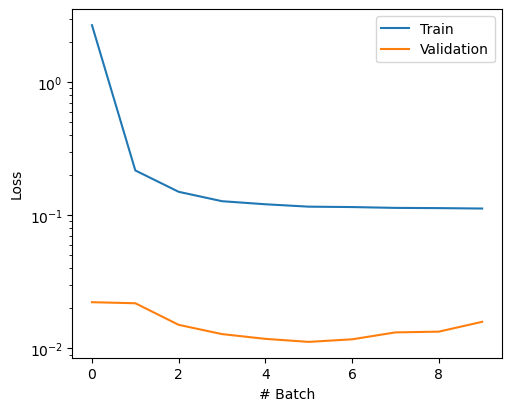

In [9]:
trainer = ANITrainer(
    model=model,
    batch_size=128,
    learning_rate=1e-3,
    epoch=10,
    l2=1e-5
)

train_loss, val_loss = trainer.train(train_data, val_data, draw_curve=True)

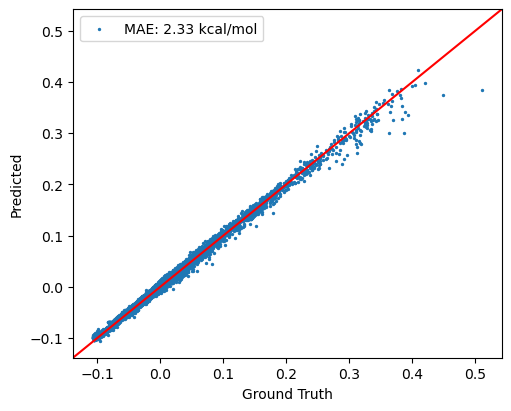

In [10]:
small_subset, _ = test_data.split(0.3, None)
test_loss = trainer.evaluate(small_subset, draw_plot=True)